In [16]:
import pandas as pd
import numpy as np

years = range(2019,2025)
returns = {}

for year in years:
    returns[year] = pd.read_parquet(f"../../data/02_clean/returns_{year-9}_{year}.parquet")
    returns[year] = np.log(1 + returns[year])
    
    # Drop columns with ALL NaNs upfront
    returns[year] = returns[year].dropna(axis=1, how='all')
    returns[year].drop(columns=["ABVC", "WKSP"], inplace=True)

common_cols = set(returns[years[0]].columns)
for year in years[1:]:
    common_cols &= set(returns[year].columns)

common_cols = sorted(list(common_cols))

# Apply common columns to all years
for year in years:
    original_cols = returns[year].shape[1]
    returns[year] = returns[year][common_cols]
    print(f"Year {year}: {original_cols} -> {returns[year].shape[1]} columns")

returns[2020] = returns[2020][returns[2020].index >= '2020-01-01']
returns[2021] = returns[2021][returns[2021].index >= '2021-01-01']
returns[2022] = returns[2022][returns[2022].index >= '2022-01-01']
returns[2023] = returns[2023][returns[2023].index >= '2023-01-01']
returns[2024] = returns[2024][returns[2024].index >= '2024-01-01']

returns_total = pd.concat(returns).reset_index(drop=False).set_index("Date").drop(columns="level_0")

Year 2019: 404 -> 401 columns
Year 2020: 403 -> 401 columns
Year 2021: 404 -> 401 columns
Year 2022: 403 -> 401 columns
Year 2023: 404 -> 401 columns
Year 2024: 403 -> 401 columns


In [17]:
temp = (
    pd.read_csv("../../data/07_portfolios_metadata/all_tickers_complete_metadata.csv")
      .replace({"#ERROR!": np.nan})
)

temp = temp[temp["Ticker"].isin(returns_total.columns)].reset_index()
beta_momentum = pd.read_csv("../../data/07_portfolios_metadata/beta_momentum.csv", index_col="Unnamed: 0")

metadata = temp.merge(beta_momentum, on="Ticker", how="left").reset_index(drop=True)
metadata["portfolio"] = "full"
mcap_cols = [col for col in metadata.columns if col.startswith("mcap_")]
metadata[mcap_cols] = (
    metadata[mcap_cols]
    .apply(lambda s: s.astype(str).str.replace(",", ".", regex=False))
    .apply(pd.to_numeric, errors="coerce")
)

In [18]:
def plot_metrics_boxplot(
    df,
    portfolios=None,
    figsize=(18, 5),
    showfliers=False,
    save=False,
    dpi=300
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import seaborn as sns
    from pathlib import Path

    out_dir = "../../figures"

    plt.style.use('seaborn-v0_8-whitegrid')
    sns.set_context("paper", font_scale=1.3)

    METRICS = [
        dict(prefix="mcap",     ylabel="Market Cap (log scale)", log_scale=True, description="Market Cap"),
        dict(prefix="beta",     ylabel="Beta",                   log_scale=False, description="Beta"),
        dict(prefix="momentum", ylabel="Momentum",               log_scale=False, description="12-month Momentum"),
    ]

    TITLE_SIZE = 15
    LABEL_SIZE = 13
    TICK_SIZE  = 11

    # n_portfolios = len(portfolios)
    palette      = sns.color_palette("colorblind", n_colors=1)
    median_colors = ["#1a1a2e", "#2e1a1a"]

    box_width = 0.30
    gap       = 0.05
    group_width = 1.0

    # offsets = np.linspace(
    #     -(n_portfolios - 1) * (box_width + gap) / 2,
    #      (n_portfolios - 1) * (box_width + gap) / 2,
    #     n_portfolios
    # )

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    for ax, metric in zip(axes, METRICS):
        prefix    = metric["prefix"]
        log_scale = metric["log_scale"]
        ylabel    = metric["ylabel"]
        description = metric["description"]

        # --- Identify & reshape ---
        metric_cols = df.columns[
            df.columns.str.match(fr"^{prefix}_\d{{4}}$")
        ].tolist()

        if len(metric_cols) == 0:
            ax.set_title(f"No data for '{prefix}'", fontsize=LABEL_SIZE)
            continue

        metric_long = df.melt(
            id_vars=["Ticker"],
            value_vars=metric_cols,
            var_name="metric_year",
            value_name="value"
        )
        metric_long["year"] = (
            metric_long["metric_year"]
            .str.replace(f"{prefix}_", "", regex=False)
            .astype(int)
        )
        metric_long = metric_long.dropna(subset=["value"])

        years   = sorted(metric_long["year"].unique())
        n_years = len(years)

        # --- Draw boxes ---
        for p_idx, (portfolio, color, med_col) in enumerate(
            zip(portfolios, palette, median_colors)
        ):
            # data_p = metric_long[metric_long["portfolio"] == portfolio]

            for y_idx, year in enumerate(years):
                values = metric_long[metric_long["year"] == year]["value"].dropna().astype(float).values
                if len(values) == 0:
                    continue

                x_pos = y_idx * group_width #+ offsets[p_idx]

                ax.boxplot(
                    values,
                    positions=[x_pos],
                    widths=box_width,
                    patch_artist=True,
                    showfliers=showfliers,
                    medianprops=dict(color=med_col,  linewidth=2.5),
                    boxprops=dict(facecolor=color,   edgecolor="black",
                                  linewidth=1.2,     alpha=0.75),
                    whiskerprops=dict(color="black", linewidth=1.2),
                    capprops=dict(color="black",     linewidth=1.2),
                    flierprops=dict(marker="o", markerfacecolor="gray",
                                    markersize=4,    alpha=0.5),
                )

        # --- Axes formatting ---
        ax.set_xticks([i * group_width for i in range(n_years)])
        ax.set_xticklabels(years, fontsize=TICK_SIZE, rotation=45)

        if log_scale:
            ax.set_yscale("log")

        ax.set_xlabel("Year",  fontsize=LABEL_SIZE, fontweight="bold", labelpad=8)
        ax.set_ylabel(ylabel,  fontsize=LABEL_SIZE, fontweight="bold", labelpad=8)
        ax.set_title(description, fontsize=TITLE_SIZE, fontweight="bold", pad=10)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(1.2)
        ax.spines["bottom"].set_linewidth(1.2)

        ax.grid(axis="y", linestyle="--", alpha=0.3, linewidth=0.8)
        ax.set_axisbelow(True)
        ax.tick_params(axis="both", which="major", labelsize=TICK_SIZE, width=1.2)

    # --- Shared legend (bottom centre) ---
    # legend_patches = [
    #     mpatches.Patch(facecolor=color, edgecolor="black", alpha=0.75, label=p.capitalize())
    #     for p, color in zip(portfolios, palette)
    # ]
    # fig.legend(
    #     handles=legend_patches,
    #     title="Portfolio",
    #     title_fontsize=10,
    #     fontsize=9,
    #     frameon=False,
    #     loc="lower center",
    #     #ncol=n_portfolios,
    #     bbox_to_anchor=(0.5, -0.05),
    # )

    plt.tight_layout()

    if save:
        out_path = Path(out_dir)
        out_path.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            out_path / "mcap_beta_momentum_evolution.png",
            dpi=dpi, bbox_inches="tight",
            facecolor="white", edgecolor="none"
        )

    plt.show()

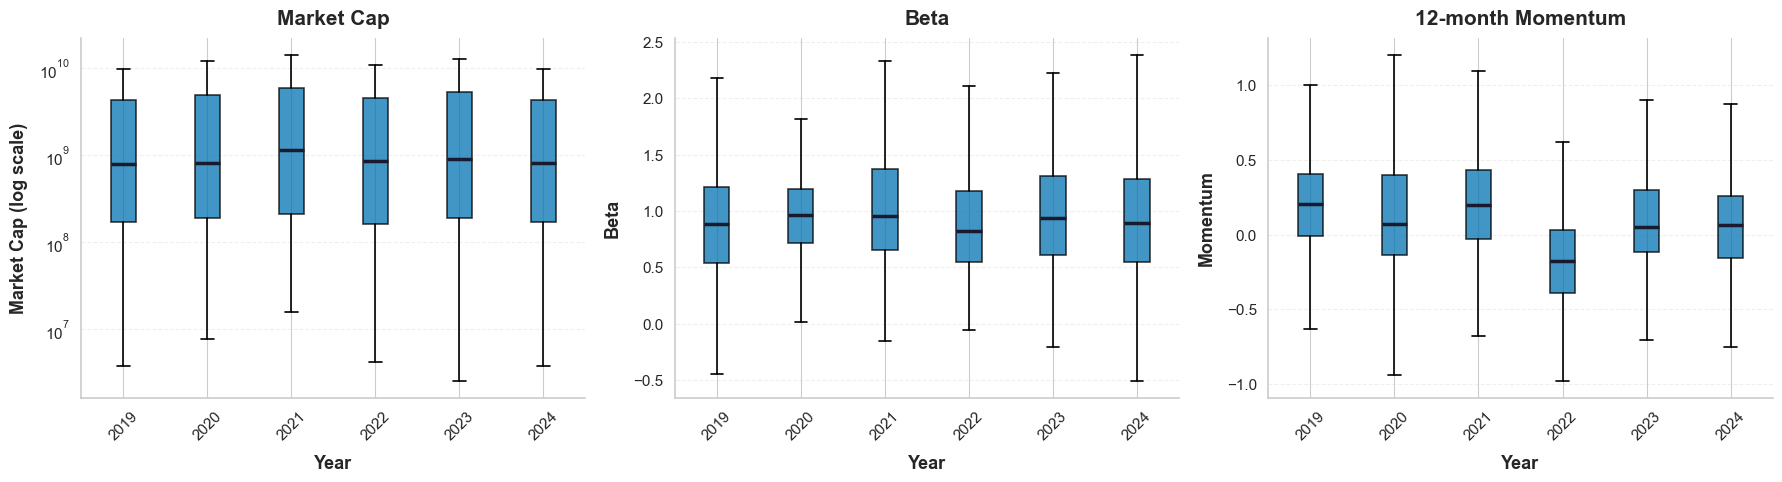

In [19]:
plot_metrics_boxplot(df=metadata, portfolios=["full"])

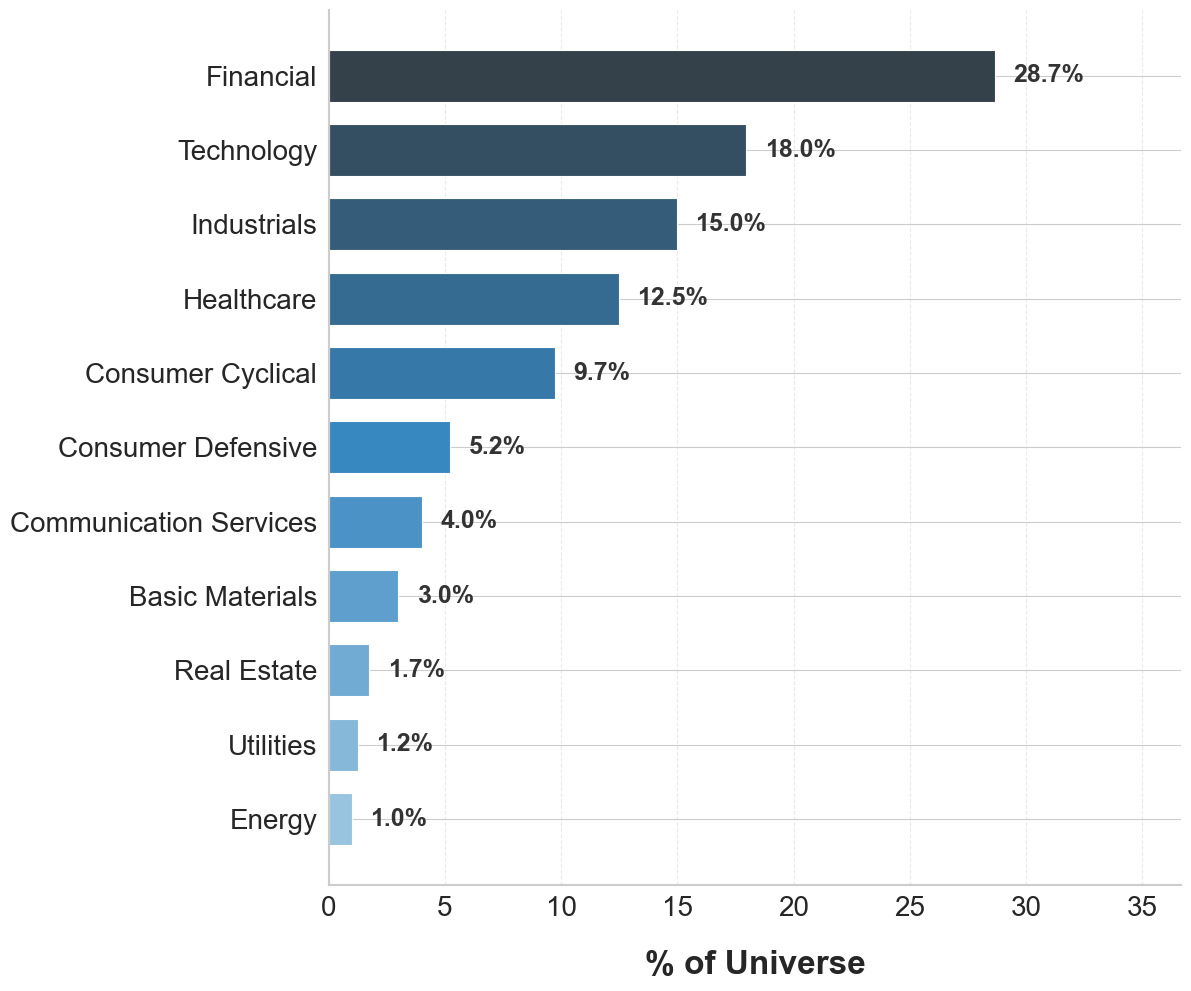

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Data processing (kept as is)
sector_counts = (
    metadata
    .groupby("Sector")
    .size()
    .reset_index(name="n_firms")
    .assign(pct=lambda x: x["n_firms"] / x["n_firms"].sum() * 100)
    .sort_values("pct", ascending=True)
)

# --- FONT SIZE CONFIGURATION ---
LABEL_SIZE = 24       # Sector names and X-axis title
TICK_SIZE = 20        # Numbers on X-axis
ANNOTATION_SIZE = 18  # Percentage values

sns.set_theme(style="whitegrid", context="paper")

# Increased figsize for a more robust "paper" look
fig, ax = plt.subplots(figsize=(12, 10))

bars = ax.barh(
    sector_counts["Sector"],
    sector_counts["pct"],
    color=sns.color_palette("Blues_d", len(sector_counts)),
    edgecolor="white",
    height=0.7,
)

# Percentage labels to the right of each bar
for bar, pct in zip(bars, sector_counts["pct"]):
    ax.text(
        bar.get_width() + 0.8, # Increased gap for larger text
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%",
        va="center", ha="left",
        fontsize=ANNOTATION_SIZE, 
        fontweight="bold",
        color="#333333"
    )

# Formatting labels and ticks
ax.set_xlabel("% of Universe", fontsize=LABEL_SIZE, fontweight="bold", labelpad=20)
ax.set_ylabel("", fontsize=LABEL_SIZE)
ax.set_xlim(0, sector_counts["pct"].max() + 8)  # More room for larger labels

ax.tick_params(axis="x", labelsize=TICK_SIZE)
ax.tick_params(axis="y", labelsize=TICK_SIZE)

# Clean up spines and grid
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../../figures/sector.png")
plt.show()

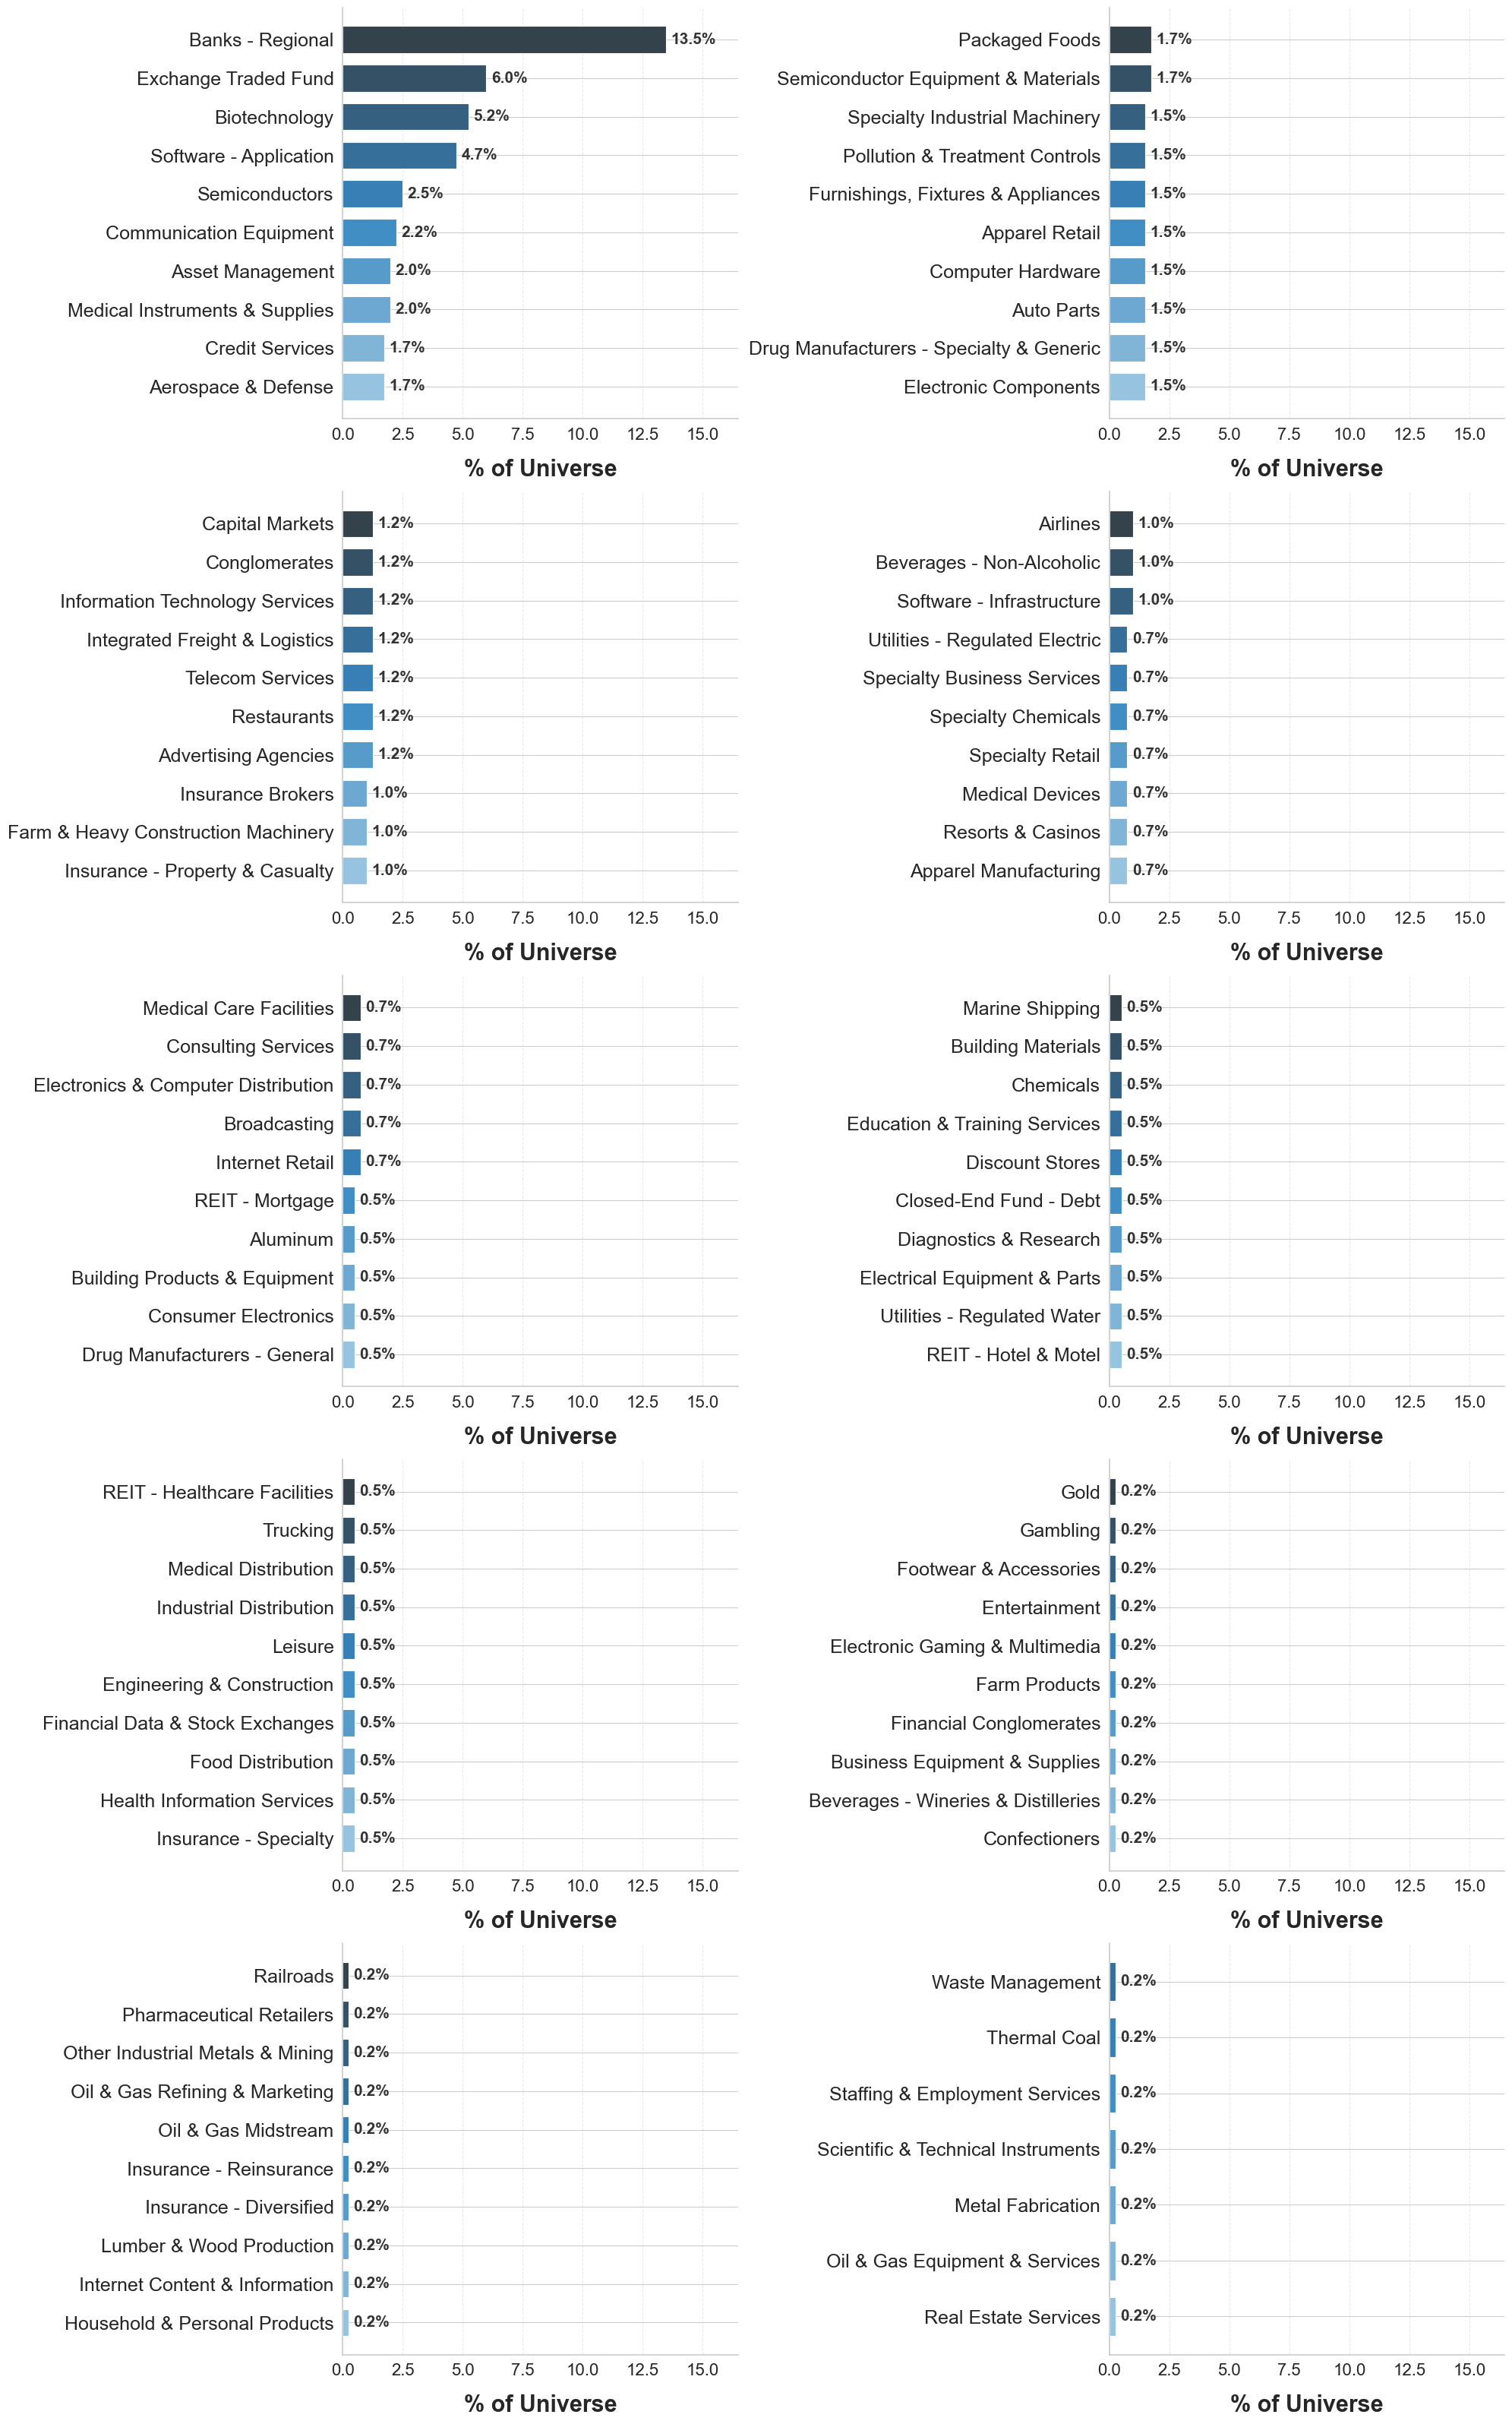

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

CHUNK_SIZE = 10  # industries per subplot

# Data processing (kept as is)
industry_counts = (
    metadata
    .groupby("Industry")
    .size()
    .reset_index(name="n_firms")
    .assign(pct=lambda x: x["n_firms"] / x["n_firms"].sum() * 100)
    .sort_values("pct", ascending=False)
    .reset_index(drop=True)
)

chunks = [
    industry_counts.iloc[i : i + CHUNK_SIZE]
    for i in range(0, len(industry_counts), CHUNK_SIZE)
]

n_chunks = len(chunks)
n_cols   = 2
n_rows   = (n_chunks + 1) // n_cols

# --- FONT SIZE CONFIGURATION FOR PAPER ---
LABEL_SIZE = 22       # Axis titles
TICK_SIZE_Y = 18      # Industry names
TICK_SIZE_X = 16      # Percentages on axis
ANNOTATION_SIZE = 15  # Text at end of bars

sns.set_theme(style="whitegrid", context="paper")

# Increased height scaling to give each industry more vertical breathing room
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(20, n_rows * CHUNK_SIZE * 0.6 + 2),
)
axes = axes.flatten()

palette = sns.color_palette("Blues_d", CHUNK_SIZE)

for ax, chunk in zip(axes, chunks):
    chunk = chunk.sort_values("pct", ascending=True)

    bars = ax.barh(
        chunk["Industry"],
        chunk["pct"],
        color=palette[: len(chunk)],
        edgecolor="white",
        height=0.7, # Slightly thicker bars
    )

    # Percentage labels to the right
    for bar, pct in zip(bars, chunk["pct"]):
        ax.text(
            bar.get_width() + 0.2, # Shifted further right
            bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%",
            va="center", ha="left",
            fontsize=ANNOTATION_SIZE, 
            fontweight="bold",
            color="#333333",
        )

    # Formatting
    ax.set_xlim(0, industry_counts["pct"].max() + 3) # Extra padding for text
    ax.set_xlabel("% of Universe", fontsize=LABEL_SIZE, fontweight="bold", labelpad=15)
    ax.set_ylabel("")
    
    # Tick Label Sizes
    ax.tick_params(axis="y", labelsize=TICK_SIZE_Y)
    ax.tick_params(axis="x", labelsize=TICK_SIZE_X)

    # Spines and Grid
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

# Hide any leftover empty axes
for ax in axes[n_chunks:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("../../figures/industry.png")
plt.show()

## Graphs

In [22]:
import networkx as nx
import pickle

years = range(2019,2025)

graphs = {}
returns = {}

base_modes = "../../data/02_clean"
k_list = [1, 10]

for year in years:
    for k in k_list:
        file_path = f"../../data/04_graphs/{year}_{k}/graph.gpickle"
        with open(file_path, "rb") as f:
            graphs[f"graph_{year}_{k}"] = pickle.load(f)

In [23]:
def compute_pozzi_centrality(G, weight_attr="weight"):
    """
    Compute the Pozzi et al. (2013) composite centrality indicators X and Y.

    X aggregates degree + betweenness (both weighted/unweighted).
    Y aggregates eccentricity + closeness + eigenvector (both weighted/unweighted).

    Weighted degree / eigenvector use edge weight  : 1 + R_ij
    Weighted BC / eccentricity / closeness use      : sqrt(2 * (1 - R_ij))  (distance)

    Parameters
    ----------
    G           : nx.Graph with a correlation edge attribute
    weight_attr : str — name of the correlation weight attribute (default "weight")

    Returns
    -------
    pd.DataFrame with columns [Du, Dw, BCu, BCw, Eu, Ew, Cu, Cw, ECu, ECw, X, Y]
    indexed by node.
    """
    N = G.number_of_nodes()

    # --- Build two edge-weighted copies ---
    G_corr = nx.Graph()   # weight = 1 + R  (similarity, for D and EC)
    G_dist = nx.Graph()   # weight = sqrt(2*(1-R))  (distance, for BC/E/C)
    G_corr.add_nodes_from(G.nodes())
    G_dist.add_nodes_from(G.nodes())

    for u, v, data in G.edges(data=True):
        r = data.get(weight_attr, 0.0)
        G_corr.add_edge(u, v, weight=1.0 + r)
        G_dist.add_edge(u, v, weight=np.sqrt(2.0 * (1.0 - r)))

    # --- Unweighted centralities (normalized to [0,1]) ---
    Du  = nx.degree_centrality(G)
    BCu = nx.betweenness_centrality(G, normalized=True)
    Cu  = nx.closeness_centrality(G)
    ECu = nx.eigenvector_centrality_numpy(G)

    # --- Weighted centralities ---
    Dw  = nx.degree_centrality(G_corr)           # similarity weights
    BCw = nx.betweenness_centrality(G_dist, weight="weight", normalized=True)
    Cw  = nx.closeness_centrality(G_dist, distance="weight")
    ECw = nx.eigenvector_centrality_numpy(G_corr, weight="weight")

    # Eccentricity requires connected graph — fall back to largest component
    def _eccentricity(Gh):
        if nx.is_connected(Gh):
            raw = nx.eccentricity(Gh)
        else:
            lcc  = Gh.subgraph(max(nx.connected_components(Gh), key=len))
            raw  = nx.eccentricity(lcc)
            # nodes outside LCC get NaN
            raw  = {n: raw.get(n, np.nan) for n in Gh.nodes()}
        # normalise: invert (higher eccentricity = more peripheral)
        # and scale to [0,1] via min-max
        vals = np.array([v for v in raw.values() if not np.isnan(v)])
        lo, hi = vals.min(), vals.max()
        return {
            n: (raw[n] - lo) / (hi - lo) if not np.isnan(raw.get(n, np.nan)) else np.nan
            for n in Gh.nodes()
        }

    Eu = _eccentricity(G)
    Ew = _eccentricity(G_dist)

    # --- Assemble DataFrame ---
    nodes = list(G.nodes())
    df = pd.DataFrame(index=nodes)

    df["Du"]  = [Du[n]  for n in nodes]
    df["Dw"]  = [Dw[n]  for n in nodes]
    df["BCu"] = [BCu[n] for n in nodes]
    df["BCw"] = [BCw[n] for n in nodes]
    df["Eu"]  = [Eu[n]  for n in nodes]
    df["Ew"]  = [Ew[n]  for n in nodes]
    df["Cu"]  = [Cu[n]  for n in nodes]
    df["Cw"]  = [Cw[n]  for n in nodes]
    df["ECu"] = [ECu[n] for n in nodes]
    df["ECw"] = [ECw[n] for n in nodes]

    # --- Composite scores (each metric already in [0,1]) ---
    df["X"] = (df["Du"] + df["Dw"] + df["BCu"] + df["BCw"]) / 4
    df["Y"] = (df["Eu"] + df["Ew"] + df["Cu"]  + df["Cw"] + df["ECu"] + df["ECw"]) / 6

    df["metric"] = df["X"] + df["Y"]

    return df


# --- Run on all graphs ---
centrality_results = {}

for year in years:
    for k in k_list:
        key = f"graph_{year}_{k}"
        print(f"Computing centrality: {key}")
        G = graphs[key]
        centrality_results[key] = compute_pozzi_centrality(G)

Computing centrality: graph_2019_1
Computing centrality: graph_2019_10
Computing centrality: graph_2020_1
Computing centrality: graph_2020_10
Computing centrality: graph_2021_1
Computing centrality: graph_2021_10
Computing centrality: graph_2022_1
Computing centrality: graph_2022_10
Computing centrality: graph_2023_1
Computing centrality: graph_2023_10
Computing centrality: graph_2024_1
Computing centrality: graph_2024_10


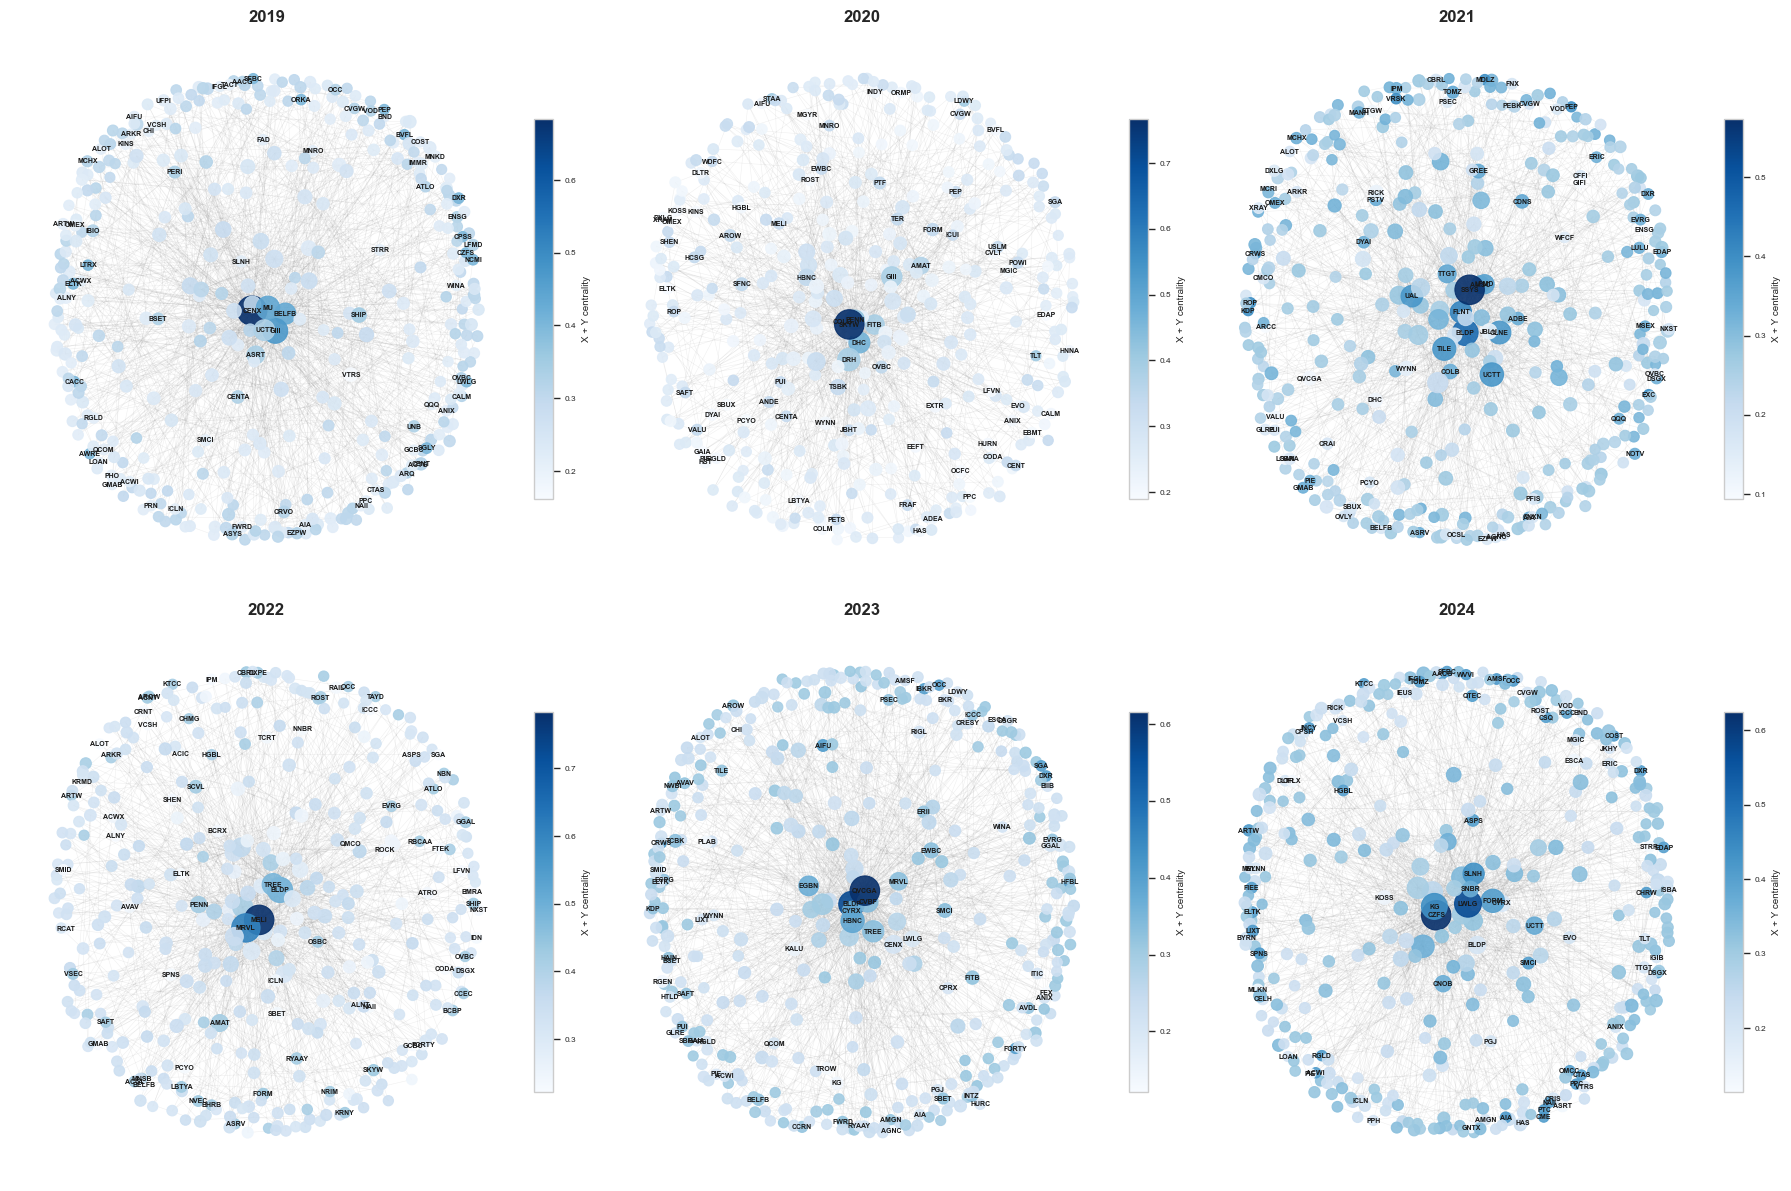

In [24]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import networkx as nx

k = 1
cmap = cm.Blues

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, year in zip(axes.flat, years):  # .flat iterates over all 6 subplots
    key  = f"graph_{year}_{k}"
    G    = graphs[key]
    cent = centrality_results[key]["metric"]

    x_min, x_max = cent.min(), cent.max()
    norm = mcolors.Normalize(vmin=x_min, vmax=x_max)

    node_colors = [cmap(norm(cent.get(n, x_min))) for n in G.nodes()]

    degree  = dict(G.degree(weight="weight"))
    max_deg = max(degree.values()) if degree else 1
    node_sizes = [50 + 400 * (degree[n] / max_deg) for n in G.nodes()]

    pos = nx.spring_layout(G, seed=42, k=0.4)

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.12, width=0.4, edge_color="grey")
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=node_sizes, alpha=0.90)

    threshold_top = cent.quantile(0.90)
    threshold_bot = cent.quantile(0.10)
    labels = {
        n: n for n in G.nodes()
        if cent.get(n, 0) >= threshold_top or cent.get(n, 0) <= threshold_bot
    }
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=5, font_weight="bold")

    ax.set_title(str(year), fontsize=12, fontweight="bold", pad=6)
    ax.axis("off")

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.035, pad=0.02, aspect=20)
    cbar.set_label("X + Y centrality", fontsize=7)
    cbar.ax.tick_params(labelsize=6)

plt.tight_layout()
plt.show()

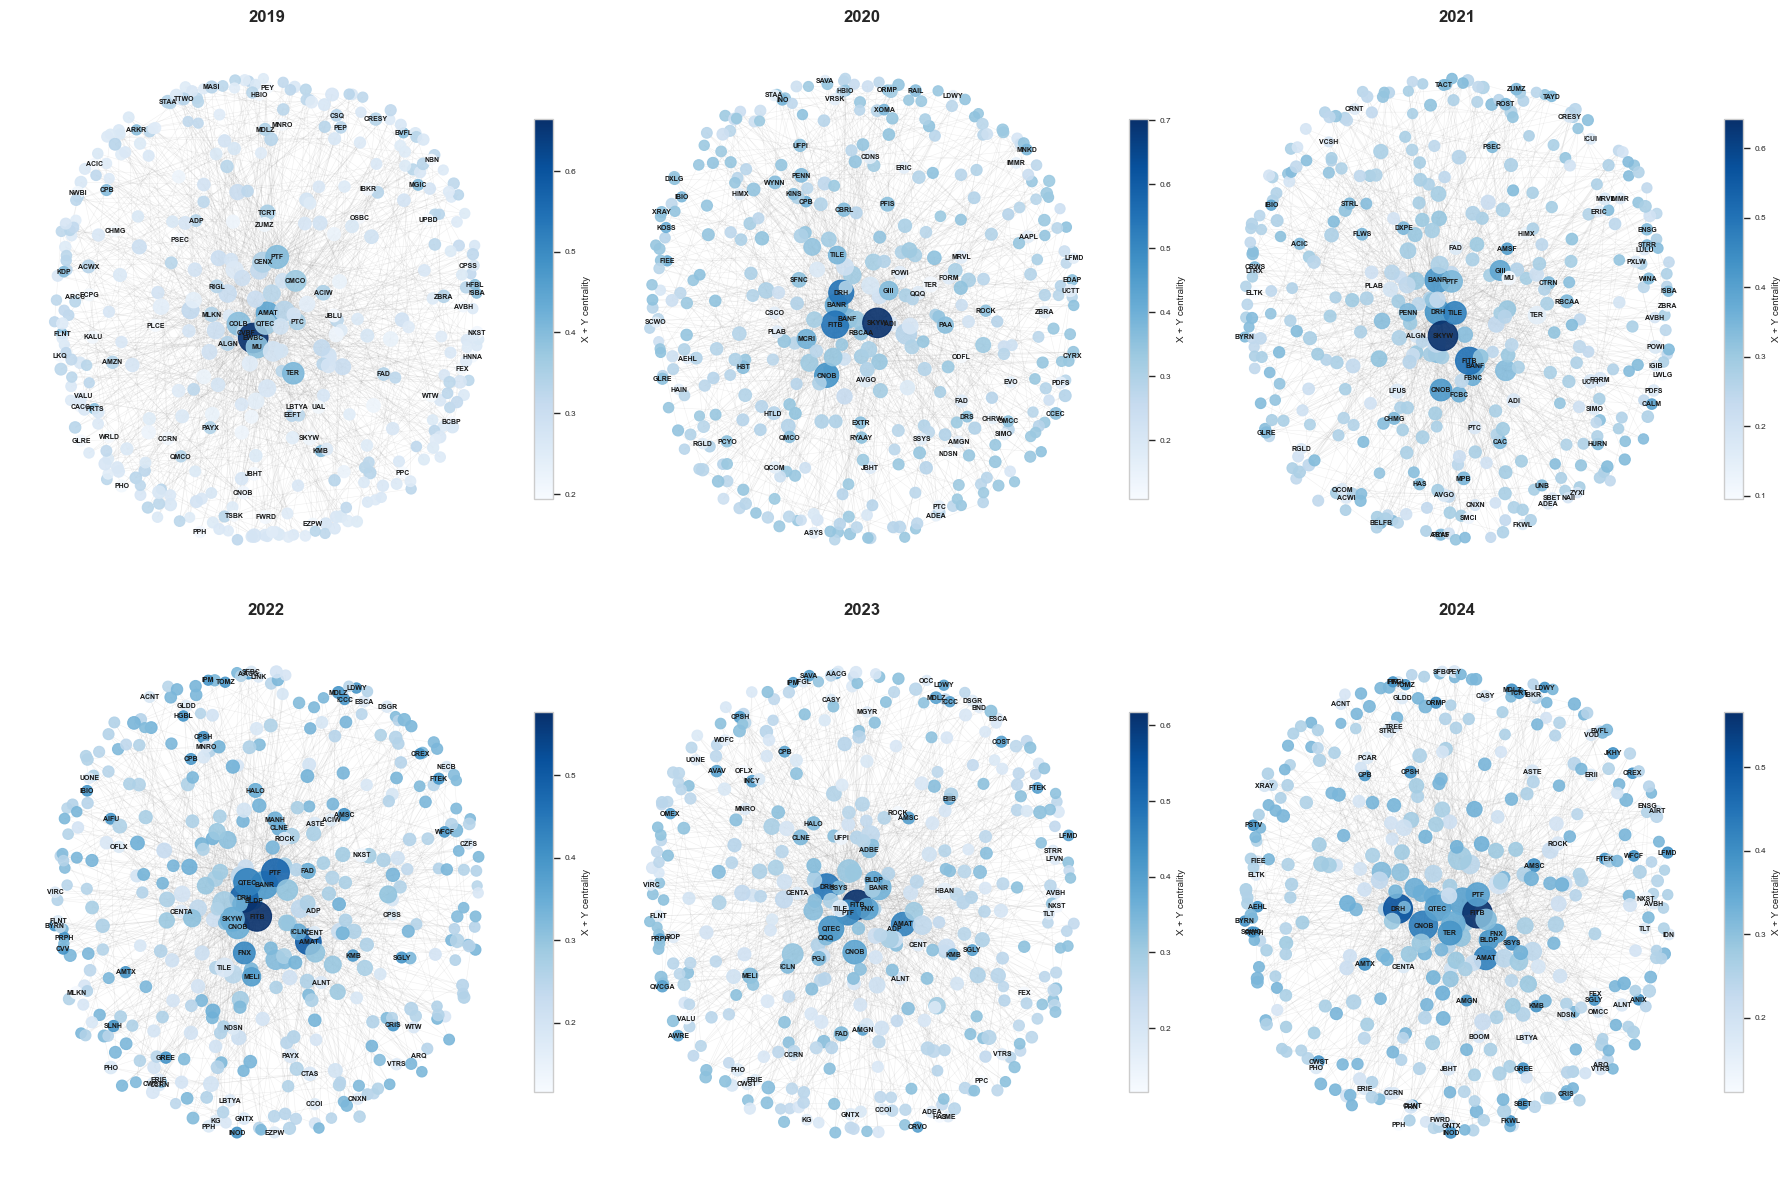

In [25]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import networkx as nx

k = 10
cmap = cm.Blues

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, year in zip(axes.flat, years):  # .flat iterates over all 6 subplots
    key  = f"graph_{year}_{k}"
    G    = graphs[key]
    cent = centrality_results[key]["metric"]

    x_min, x_max = cent.min(), cent.max()
    norm = mcolors.Normalize(vmin=x_min, vmax=x_max)

    node_colors = [cmap(norm(cent.get(n, x_min))) for n in G.nodes()]

    degree  = dict(G.degree(weight="weight"))
    max_deg = max(degree.values()) if degree else 1
    node_sizes = [50 + 400 * (degree[n] / max_deg) for n in G.nodes()]

    pos = nx.spring_layout(G, seed=42, k=0.4)

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.12, width=0.4, edge_color="grey")
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=node_sizes, alpha=0.90)

    threshold_top = cent.quantile(0.90)
    threshold_bot = cent.quantile(0.10)
    labels = {
        n: n for n in G.nodes()
        if cent.get(n, 0) >= threshold_top or cent.get(n, 0) <= threshold_bot
    }
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=5, font_weight="bold")

    ax.set_title(str(year), fontsize=12, fontweight="bold", pad=6)
    ax.axis("off")

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.035, pad=0.02, aspect=20)
    cbar.set_label("X + Y centrality", fontsize=7)
    cbar.ax.tick_params(labelsize=6)

plt.tight_layout()
plt.show()

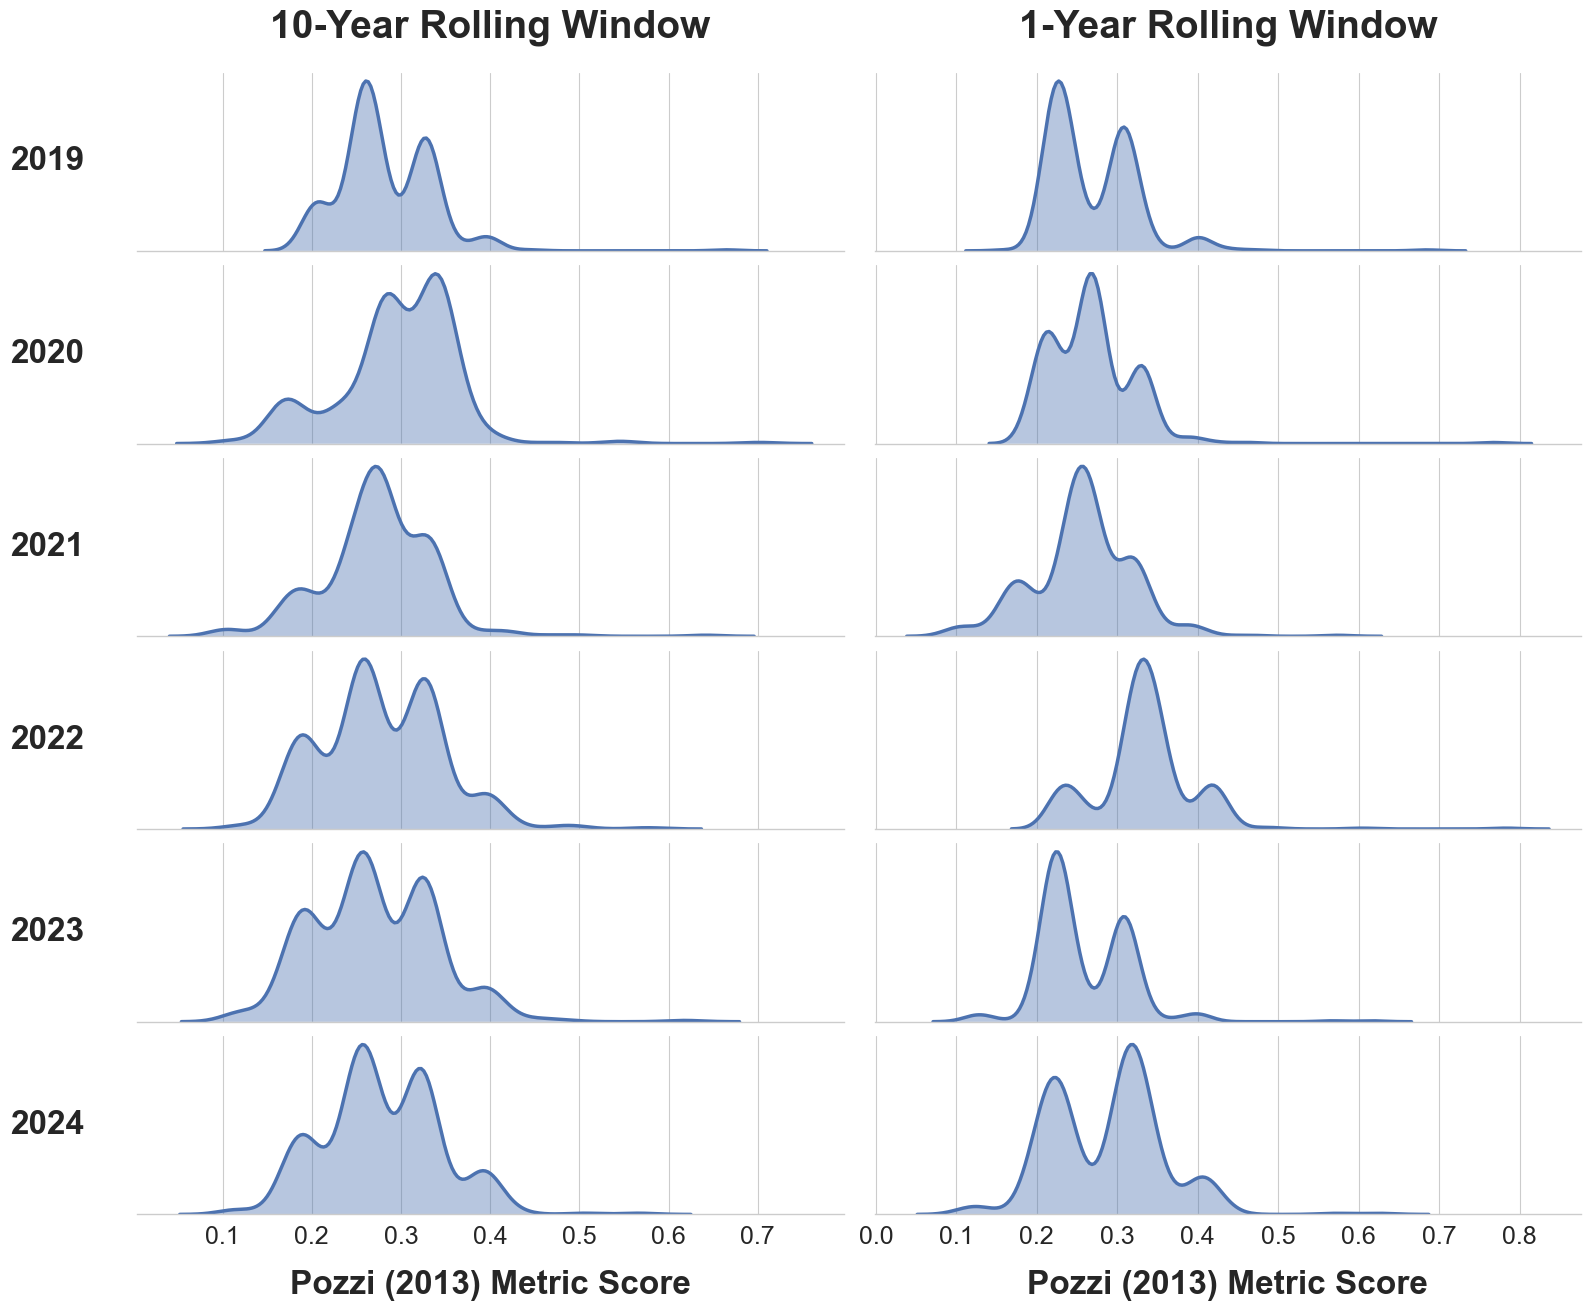

In [26]:
# Configuration for Paper-Ready Fonts
COLUMN_TITLE_SIZE = 28
ROW_LABEL_SIZE = 24
X_LABEL_SIZE = 24
TICK_SIZE = 18

# Increased figure height scaling for better vertical separation
fig, axes = plt.subplots(len(years), 2, figsize=(16, len(years) * 2.2), sharex="col")
k_list = [10, 1]

for col_idx, k in enumerate(k_list):
    for row_idx, year in enumerate(years):
        ax = axes[row_idx, col_idx]
        # Data fetching (metric refers to your hybrid_risk_metric results)
        data = centrality_results[f"graph_{year}_{k}"]["metric"].dropna().astype(float)

        # Plotting density
        sns.kdeplot(data, ax=ax)
        line = ax.get_lines()[0]
        x, y = line.get_data()
        ax.fill_between(x, y, alpha=0.4)
        line.set_linewidth(2.5) # Thicker line for paper clarity

        # Year Labels (Left column only)
        if col_idx == 0:
            ax.set_ylabel(str(year), fontsize=ROW_LABEL_SIZE, fontweight="bold",
                          rotation=0, labelpad=65, va="center")
        else:
            ax.set_ylabel("")

        # Formatting
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.set_yticks([])
        ax.tick_params(axis='x', labelsize=TICK_SIZE)

    # Column Titles (Top row only)
    if k == 10: 
        axes[0, col_idx].set_title("10-Year Rolling Window", fontsize=COLUMN_TITLE_SIZE, fontweight="bold", pad=25)
    elif k == 1: 
        axes[0, col_idx].set_title("1-Year Rolling Window", fontsize=COLUMN_TITLE_SIZE, fontweight="bold", pad=25)
    
    # X-Axis Label (Bottom row only)
    axes[-1, col_idx].set_xlabel("Pozzi (2013) Metric Score", fontsize=X_LABEL_SIZE, fontweight="bold", labelpad=15)

# Adjust spacing to overlap rows slightly for "Joyplot" effect if desired
plt.subplots_adjust(hspace=-0.15) 
plt.tight_layout()
plt.savefig("../../figures/pozzidist.png")
plt.show()

## Our metric

In [27]:
import community as community_louvain

def calculate_hybrid_risk_metric(G, weights=None):
    # Default equal weights if not provided
    if weights is None:
        weights = {
            'degree': 1/3,
            'closeness': 1/3,
            'betweenness': 0,
            'eigenvector': 1/3
        }
    
    nodes = list(G.nodes)

    G = G.copy()
    for u, v, d in G.edges(data=True):
        d["distance"] = 1 / abs(d["weight"]) if d["weight"] != 0 else np.inf
    
    # 1. Calculate raw metrics
    
    # Degree
    degree_dict = dict(nx.degree(G, weight="weight"))
    
    # Clustering coefficient
    closeness_dict = nx.closeness_centrality(G, distance="distance")
    
    # Betweenness centrality
    betweenness_dict = nx.betweenness_centrality(G, weight='distance', normalized=True)
    
    # Eigenvector centrality
    eig_dict = nx.eigenvector_centrality(G, weight="weight")
    
    # 2. Normalize metrics (0=lowest risk, 1=highest risk)
    def normalize_dict(d, invert=False):
        vals = np.array(list(d.values()))
        min_val = vals.min()
        max_val = vals.max()
        if max_val - min_val == 0:
            # Avoid division by zero if all values equal
            return {k: 0.0 for k in d.keys()}
        norm = {k: (v - min_val) / (max_val - min_val) for k, v in d.items()}
        if invert:
            norm = {k: 1 - v for k, v in norm.items()}
        return norm
    
    norm_degree = normalize_dict(degree_dict, invert=False)
    norm_closeness = normalize_dict(closeness_dict, invert=False)
    norm_betweenness = normalize_dict(betweenness_dict, invert=False)
    norm_eig = normalize_dict(eig_dict, invert=False)
    
    # 3. Combine metrics with weights
    risk_scores = {}
    for node in nodes:
        score = (
            weights['degree'] * norm_degree[node] +
            weights['closeness'] * norm_closeness[node] +
            weights['betweenness'] * norm_betweenness[node] +
            weights['eigenvector'] * norm_eig[node] 
        )
        risk_scores[node] = score
    
    return risk_scores

# --- Compute hybrid risk metric for all graphs ---
hybrid_risk_results = {}

for year in years:
    for k in k_list:
        key = f"graph_{year}_{k}"
        scores = calculate_hybrid_risk_metric(graphs[key])
        hybrid_risk_results[key] = pd.Series(scores, name="HRM")

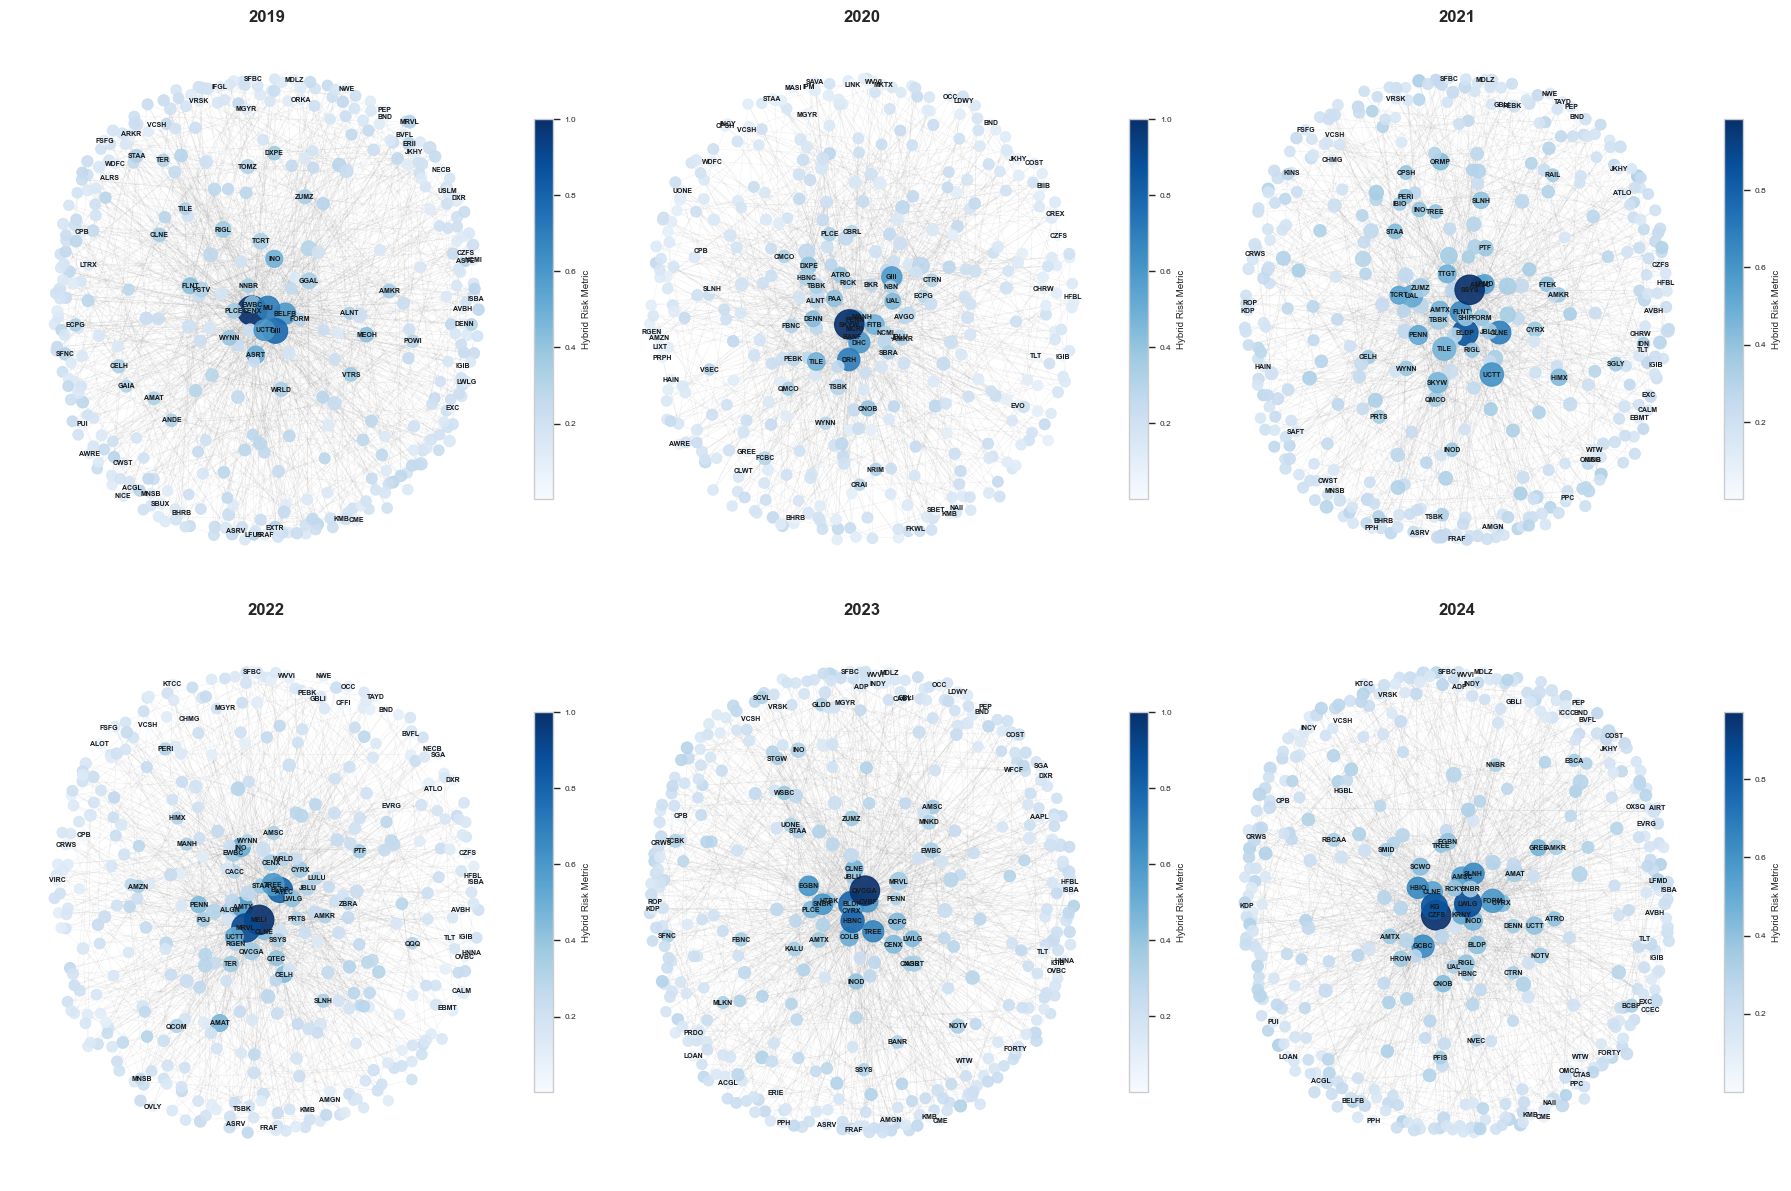

In [28]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import networkx as nx

k = 1
cmap = cm.Blues  # Reds fits "risk" semantics better than Blues

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, year in zip(axes.flat, years):
    key  = f"graph_{year}_{k}"
    G    = graphs[key]
    hrm  = hybrid_risk_results[key]          # pd.Series, no ["HRM"] needed

    h_min, h_max = hrm.min(), hrm.max()
    norm = mcolors.Normalize(vmin=h_min, vmax=h_max)

    node_colors = [cmap(norm(hrm.get(n, h_min))) for n in G.nodes()]

    degree  = dict(G.degree(weight="weight"))
    max_deg = max(degree.values()) if degree else 1
    node_sizes = [50 + 400 * (degree[n] / max_deg) for n in G.nodes()]

    pos = nx.spring_layout(G, seed=42, k=0.4)

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.12, width=0.4, edge_color="grey")
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=node_sizes, alpha=0.90)

    threshold_top = hrm.quantile(0.90)
    threshold_bot = hrm.quantile(0.10)
    labels = {
        n: n for n in G.nodes()
        if hrm.get(n, 0) >= threshold_top or hrm.get(n, 0) <= threshold_bot
    }
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=5, font_weight="bold")

    ax.set_title(str(year), fontsize=12, fontweight="bold", pad=6)
    ax.axis("off")

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.035, pad=0.02, aspect=20)
    cbar.set_label("Hybrid Risk Metric", fontsize=7)
    cbar.ax.tick_params(labelsize=6)

plt.tight_layout()
plt.show()

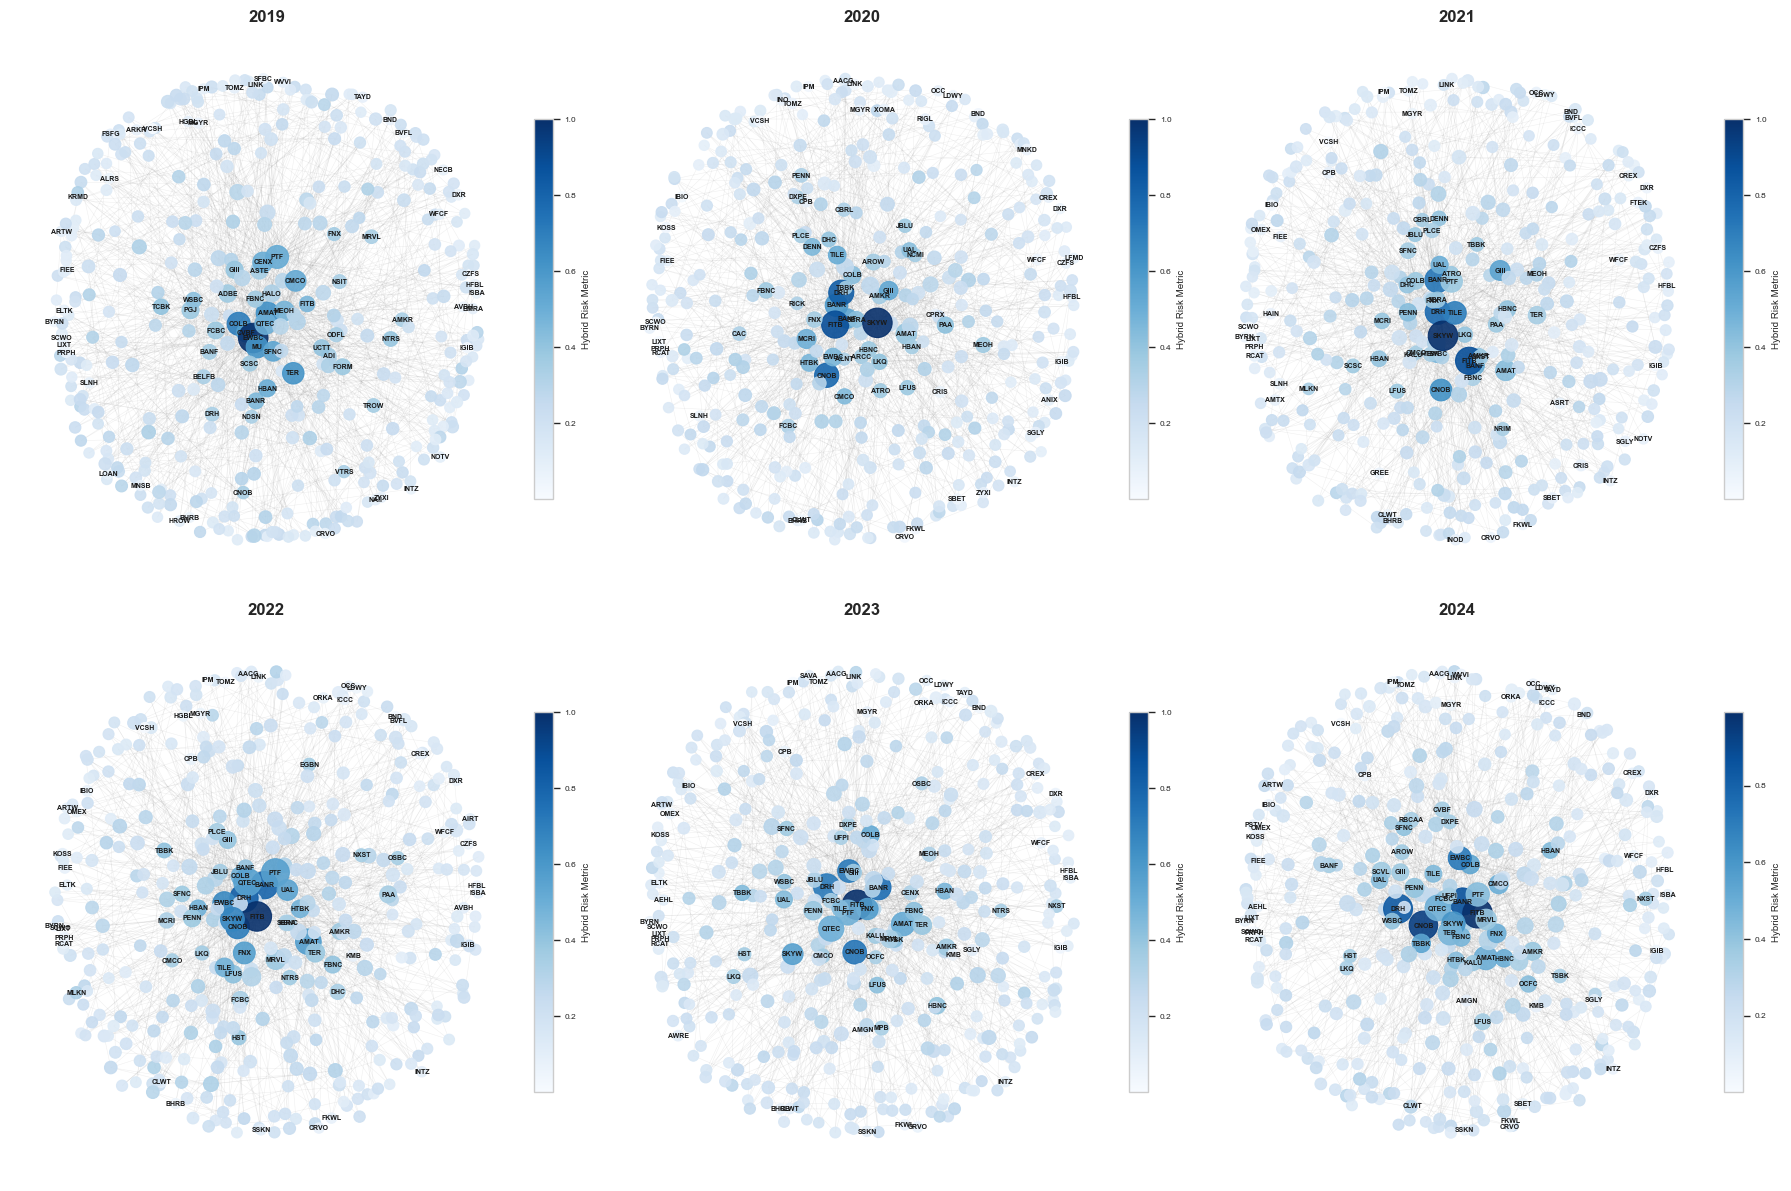

In [29]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import networkx as nx

k = 10
cmap = cm.Blues  # Reds fits "risk" semantics better than Blues

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, year in zip(axes.flat, years):
    key  = f"graph_{year}_{k}"
    G    = graphs[key]
    hrm  = hybrid_risk_results[key]          # pd.Series, no ["HRM"] needed

    h_min, h_max = hrm.min(), hrm.max()
    norm = mcolors.Normalize(vmin=h_min, vmax=h_max)

    node_colors = [cmap(norm(hrm.get(n, h_min))) for n in G.nodes()]

    degree  = dict(G.degree(weight="weight"))
    max_deg = max(degree.values()) if degree else 1
    node_sizes = [50 + 400 * (degree[n] / max_deg) for n in G.nodes()]

    pos = nx.spring_layout(G, seed=42, k=0.4)

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.12, width=0.4, edge_color="grey")
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=node_sizes, alpha=0.90)

    threshold_top = hrm.quantile(0.90)
    threshold_bot = hrm.quantile(0.10)
    labels = {
        n: n for n in G.nodes()
        if hrm.get(n, 0) >= threshold_top or hrm.get(n, 0) <= threshold_bot
    }
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=5, font_weight="bold")

    ax.set_title(str(year), fontsize=12, fontweight="bold", pad=6)
    ax.axis("off")

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.035, pad=0.02, aspect=20)
    cbar.set_label("Hybrid Risk Metric", fontsize=7)
    cbar.ax.tick_params(labelsize=6)

plt.tight_layout()
plt.show()

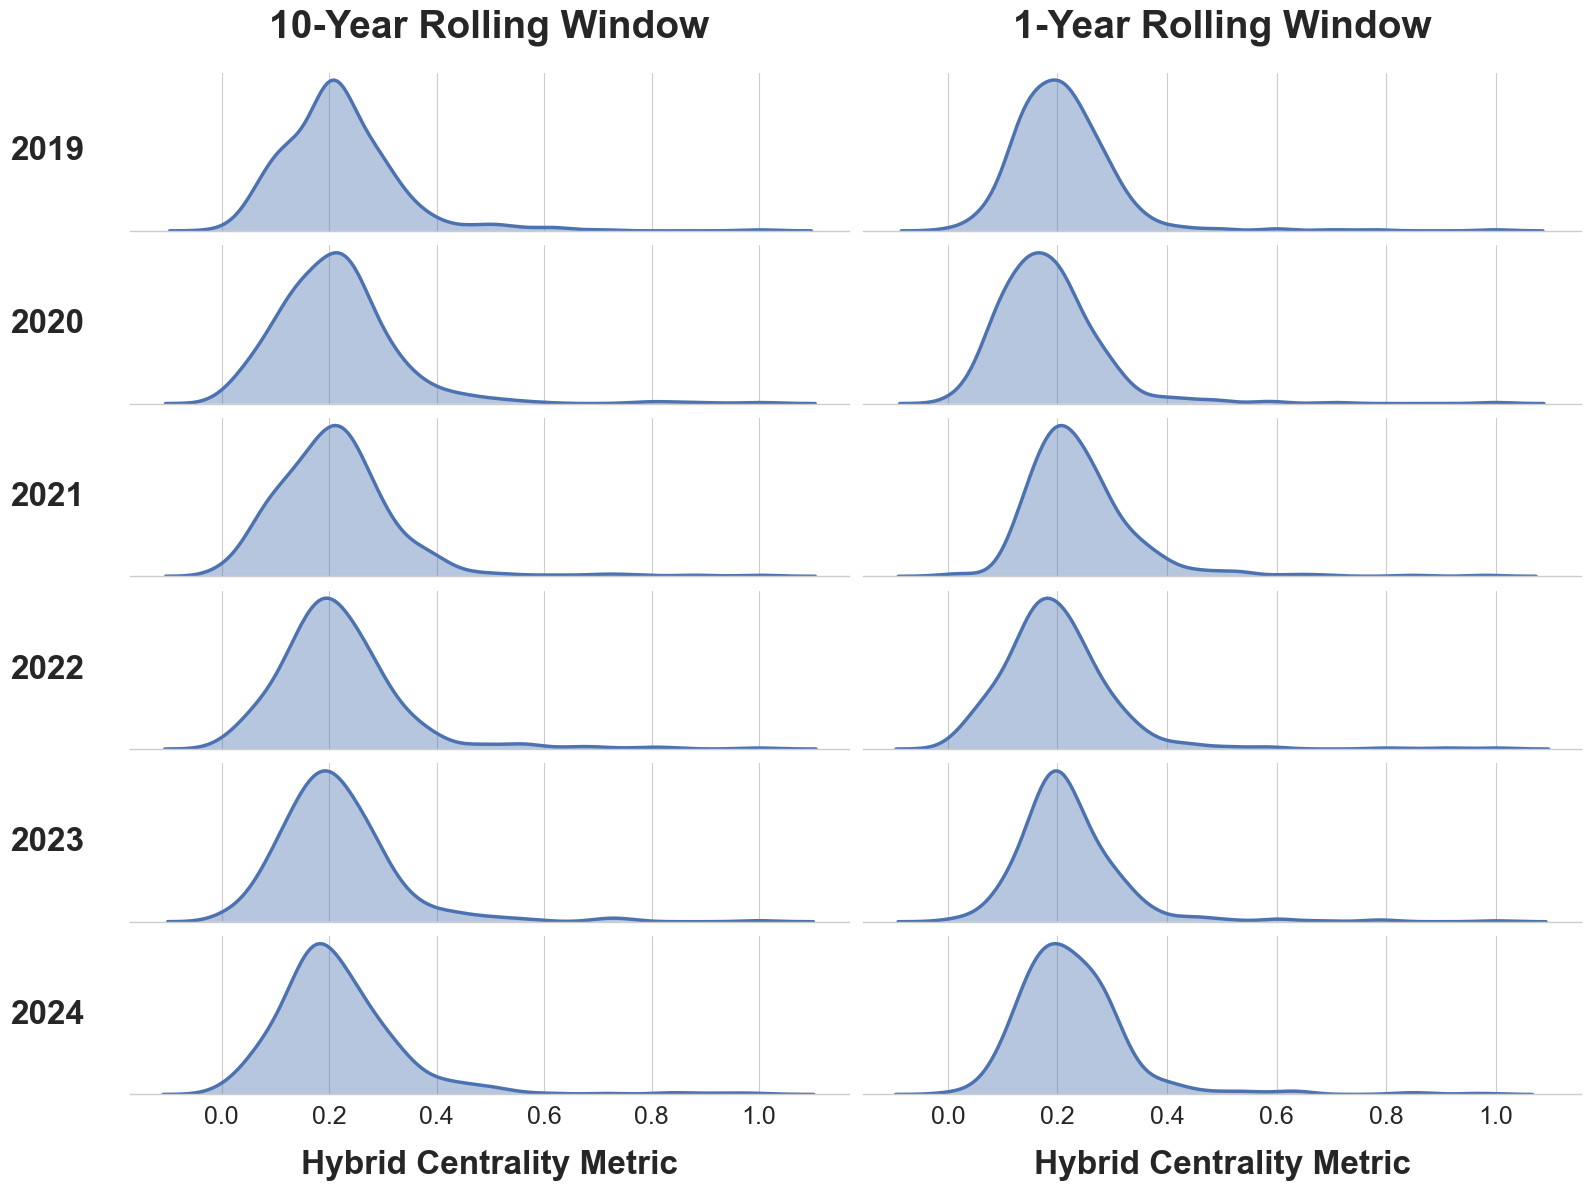

In [30]:
# --- FONT SIZE CONFIGURATION FOR PAPER ---
COLUMN_TITLE_SIZE = 28
ROW_LABEL_SIZE = 24
X_LABEL_SIZE = 24
TICK_SIZE = 18

# Increased vertical scaling to give larger text room to breathe
fig, axes = plt.subplots(
    len(years), 2, 
    figsize=(16, len(years) * 2.0), 
    sharex="col"
)

k_list_ = [10, 1]  # col 0: k=10, col 1: k=1

for col_idx, k in enumerate(k_list_):
    for row_idx, year in enumerate(years):
        ax = axes[row_idx, col_idx]
        data = hybrid_risk_results[f"graph_{year}_{k}"].dropna().astype(float)

        # Plot KDE
        sns.kdeplot(data, ax=ax)
        line = ax.get_lines()[0]
        x_data, y_data = line.get_data()
        ax.fill_between(x_data, y_data, alpha=0.4)
        line.set_linewidth(2.5) # Thicker lines for paper clarity

        # Row Labels (Years) - Only on the far left
        if col_idx == 0:
            ax.set_ylabel(
                str(year), 
                fontsize=ROW_LABEL_SIZE, 
                fontweight="bold",
                rotation=0, 
                labelpad=60, # Increased pad for larger font
                va="center"
            )
        else:
            ax.set_ylabel("")

        # Cleaning up spines and ticks
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.set_yticks([])
        
        # Increase X-tick label size (numbers)
        ax.tick_params(axis='x', labelsize=TICK_SIZE)

    # Column Titles - Applied only to the top row
    if k == 10: 
        axes[0, col_idx].set_title("10-Year Rolling Window", fontsize=COLUMN_TITLE_SIZE, fontweight="bold", pad=25)
    elif k == 1: 
        axes[0, col_idx].set_title("1-Year Rolling Window", fontsize=COLUMN_TITLE_SIZE, fontweight="bold", pad=25)
    
    # X-Axis Labels - Applied only to the bottom row
    axes[-1, col_idx].set_xlabel("Hybrid Centrality Metric", fontsize=X_LABEL_SIZE, fontweight="bold", labelpad=15)

# Adjust overlap: hspace < 0 creates the "joyplot" look. 
# Use hspace=0 or small positive values if you want the rows separated.
plt.subplots_adjust(hspace=-0.1) 

plt.tight_layout()
plt.savefig("../../figures/hcm_dist.png")
plt.show()